# Task 8 - Machine Learning with Linear Regression
House Price Prediction System

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


## Create Dataset

In [2]:
df=pd.DataFrame({
'HouseID':['H001','H002','H003','H004','H005','H006','H007','H008','H009','H010'],
'Area':[1200,1500,1800,2200,2500,3000,1700,2100,2600,3200],
'Bedrooms':[2,3,3,4,4,5,3,4,4,5],
'Bathrooms':[2,2,3,3,4,4,2,3,4,5],
'Parking':[1,1,2,2,2,3,1,2,2,3],
'Age':[10,8,5,4,2,1,6,3,2,1],
'Price':[45,60,72,90,110,135,68,88,115,145]
})
df.to_csv('house_price_prediction.csv',index=False)
df.head()


,HouseID,Area,Bedrooms,Bathrooms,Parking,Age,Price
0,H001,1200,2,2,1,10,45
1,H002,1500,3,2,1,8,60
2,H003,1800,3,3,2,5,72
3,H004,2200,4,3,2,4,90
4,H005,2500,4,4,2,2,110


## Data Preparation

In [3]:
print(df.info())
print(df.isnull().sum())
print(df.describe())

X=df[['Area','Bedrooms','Bathrooms','Parking','Age']]
y=df['Price']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   HouseID    10 non-null     object
 1   Area       10 non-null     int64 
 2   Bedrooms   10 non-null     int64 
 3   Bathrooms  10 non-null     int64 
 4   Parking    10 non-null     int64 
 5   Age        10 non-null     int64 
 6   Price      10 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 692.0+ bytes
None
HouseID      0
Area         0
Bedrooms     0
Bathrooms    0
Parking      0
Age          0
Price        0
dtype: int64
              Area   Bedrooms  Bathrooms    Parking        Age       Price
count    10.000000  10.000000  10.000000  10.000000  10.000000   10.000000
mean   2180.000000   3.700000   3.200000   1.900000   4.200000   92.800000
std     649.444207   0.948683   1.032796   0.737865   3.047768   32.886336
min    1200.000000   2.000000   2.000000   1.000000   1.000000   45.00

## Train Model

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

pred=model.predict(X_test)

print("Model Score:",model.score(X_test,y_test))


Model Score: 0.9947300503599651


## Evaluation

In [5]:
mae=mean_absolute_error(y_test,pred)
mse=mean_squared_error(y_test,pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,pred)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)


MAE: 1.5690376569037738
MSE: 3.9853994152763623
RMSE: 1.99634651683428
R2: 0.9947300503599651


## Visualizations

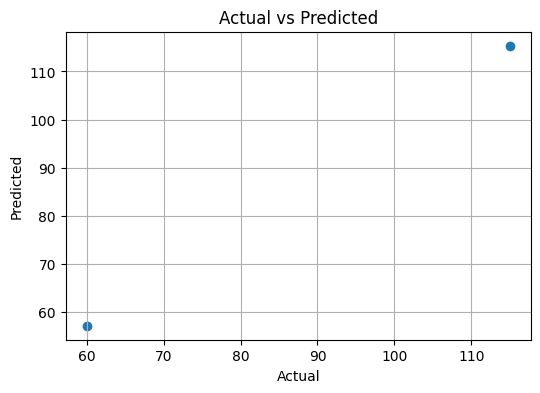

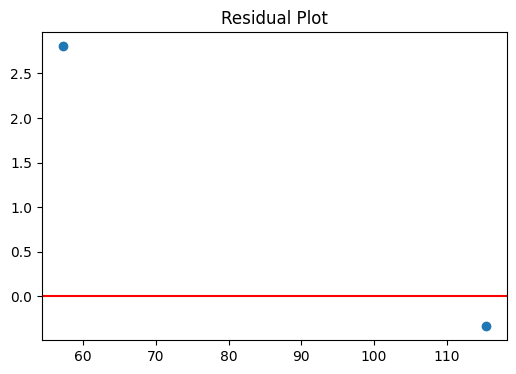

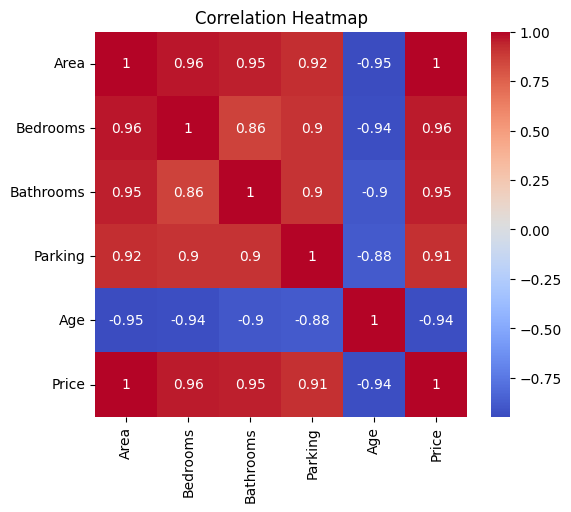

In [6]:
plt.figure(figsize=(6,4))
plt.scatter(y_test,pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid()
plt.savefig("actual_vs_predicted.png")
plt.show()

res=y_test-pred
plt.figure(figsize=(6,4))
plt.scatter(pred,res)
plt.axhline(0,color='r')
plt.title("Residual Plot")
plt.savefig("residual_plot.png")
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(df.drop(columns='HouseID').corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()


## Predict New House

In [7]:
new_house=pd.DataFrame({
'Area':[2400],
'Bedrooms':[4],
'Bathrooms':[3],
'Parking':[2],
'Age':[3]
})

price=model.predict(new_house)
print("Predicted Price:",price[0])


Predicted Price: 103.8619246861925


## Save and Load Model

In [8]:
joblib.dump(model,'house_price_model.pkl')

loaded=joblib.load('house_price_model.pkl')
print(loaded.predict(new_house))


[103.86192469]


## Practical 1 - Student Marks Prediction

In [9]:
marks=pd.DataFrame({'StudyHours':[2,3,4,5,6,7,8,9],
'Marks':[35,45,52,60,68,75,85,92]})
X=marks[['StudyHours']]
y=marks['Marks']
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.25,random_state=42)
m=LinearRegression().fit(Xtr,ytr)
print("5.5 Hours:",m.predict([[5.5]])[0])
print("7.5 Hours:",m.predict([[7.5]])[0])
print("MAE:",mean_absolute_error(yte,m.predict(Xte)))
print("R2:",r2_score(yte,m.predict(Xte)))


5.5 Hours: 63.96999999999999
7.5 Hours: 80.32999999999998
MAE: 1.3599999999999923
R2: 0.9917155555555557


C:\Users\anujr\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\anujr\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Practical 2 - House Price Prediction

In [10]:
house=pd.DataFrame({'Area':[1200,1500,1800,2200,2500,3000],
'Bedrooms':[2,3,3,4,4,5],
'Price':[45,60,72,90,110,135]})
X=house[['Area','Bedrooms']]
y=house['Price']
m=LinearRegression().fit(X,y)
print("Prediction:",m.predict([[2000,3]])[0])


Prediction: 84.95652173913042


C:\Users\anujr\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Practical 3 - Salary Prediction

In [11]:
sal=pd.DataFrame({'Experience':[1,2,3,5,7,10],'Salary':[25000,30000,38000,55000,72000,100000]})
X=sal[['Experience']]
y=sal['Salary']
m=LinearRegression().fit(X,y)
print("4 Years:",m.predict([[4]])[0])
print("8 Years:",m.predict([[8]])[0])


4 Years: 47697.674418604656
8 Years: 81511.62790697673


C:\Users\anujr\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\anujr\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Practical 4 - Sales Prediction

In [12]:
sales=pd.DataFrame({'Advertising':[1000,1500,2000,2500,3000],'Sales':[120,160,210,260,300]})
m=LinearRegression().fit(sales[['Advertising']],sales['Sales'])
print("Sales Prediction:",m.predict([[2200]])[0])


Sales Prediction: 228.4


C:\Users\anujr\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Practical 5 - Employee Performance Prediction

In [13]:
emp=pd.DataFrame({'TrainingHours':[10,15,20,25,30,35],'PerformanceScore':[55,62,70,78,85,92]})
m=LinearRegression().fit(emp[['TrainingHours']],emp['PerformanceScore'])
print("Performance:",m.predict([[28]])[0])


Performance: 81.90095238095239


C:\Users\anujr\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
